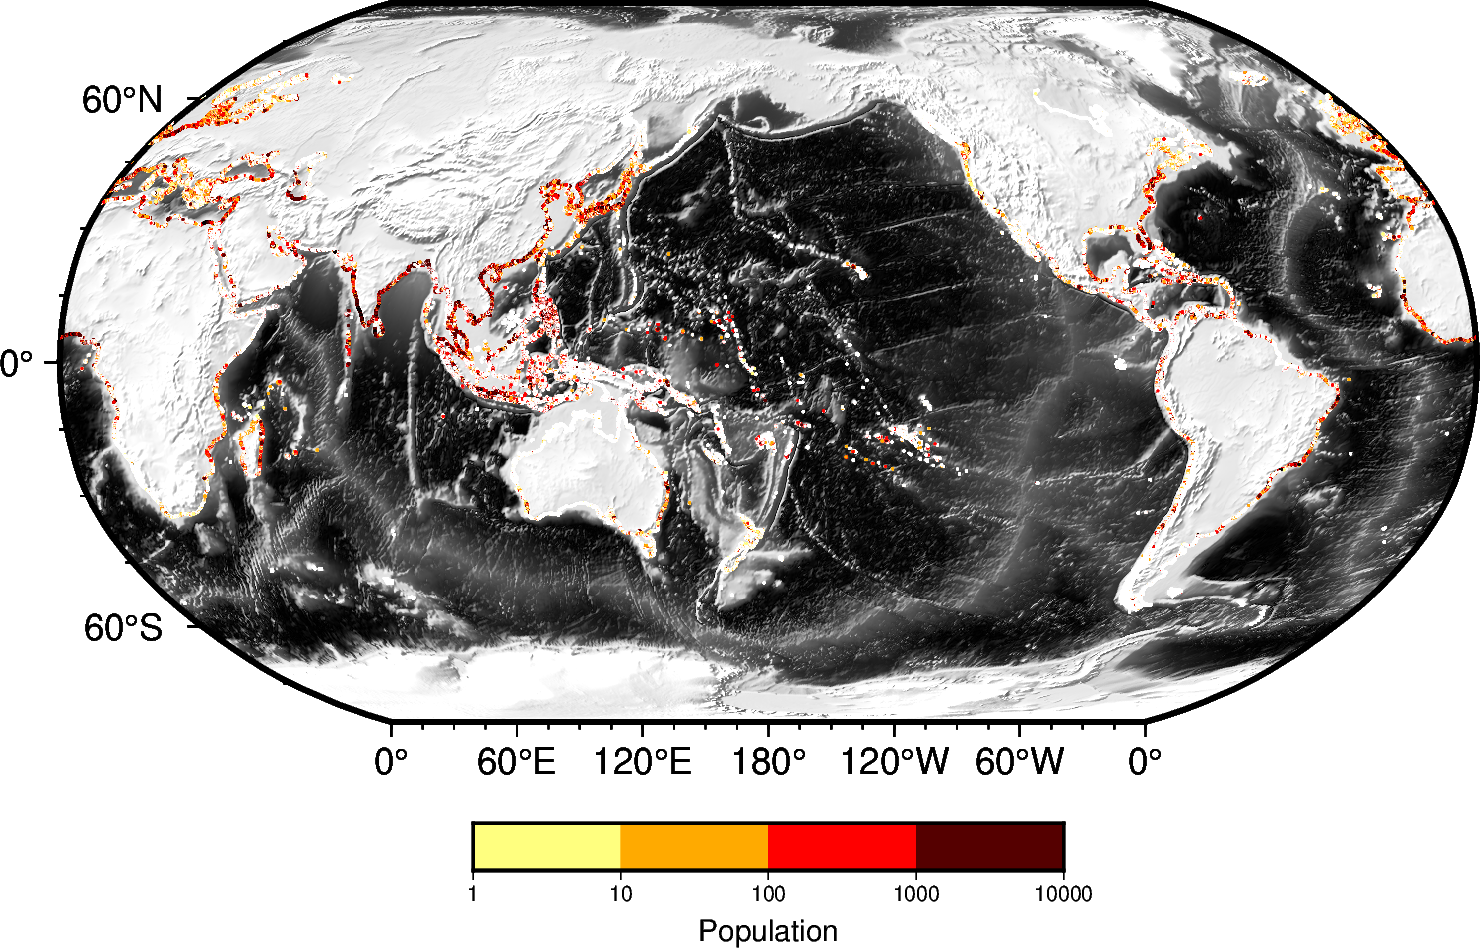

In [2]:
import pandas as pd
import pygmt

#csv files
ptha = pd.read_csv('./revised1_tsunami_runup_at_fixed_return_periods.csv')
pop = pd.read_csv('./GCC_socioeconomic.csv')

# Load the elevation grid globally for the whole Earth
grid = pygmt.datasets.load_earth_relief(resolution="15m")

#plot bathy and topography
fig = pygmt.Figure()
fig.basemap(region="g", projection="N12c", frame=True)
pygmt.makecpt(cmap="gray", series=[-5000, 500],transparency=80)
fig.grdimage(shading=True,frame=True, grid=grid,cmap=True,projection="N12c")

#plot coast
# fig.coast(shorelines="0.1p,black,solid",region="g",projection="N12c")

#plots pop 
cmap = pygmt.makecpt(cmap='hot',log=True, series = [0,4,1],reverse=True)
fig.plot(x=pop.lon, y=pop.lat,cmap=True,style='p0.02c',fill=pop.pop_5_m,pen=None,projection="N12c")
fig.colorbar(frame=["x+lPopulation"], position="JBC+w5c/0.4c",log = True) #add colorbar legend for scatter
 
fig.savefig('pop_map.png',dpi=300)
fig.show()


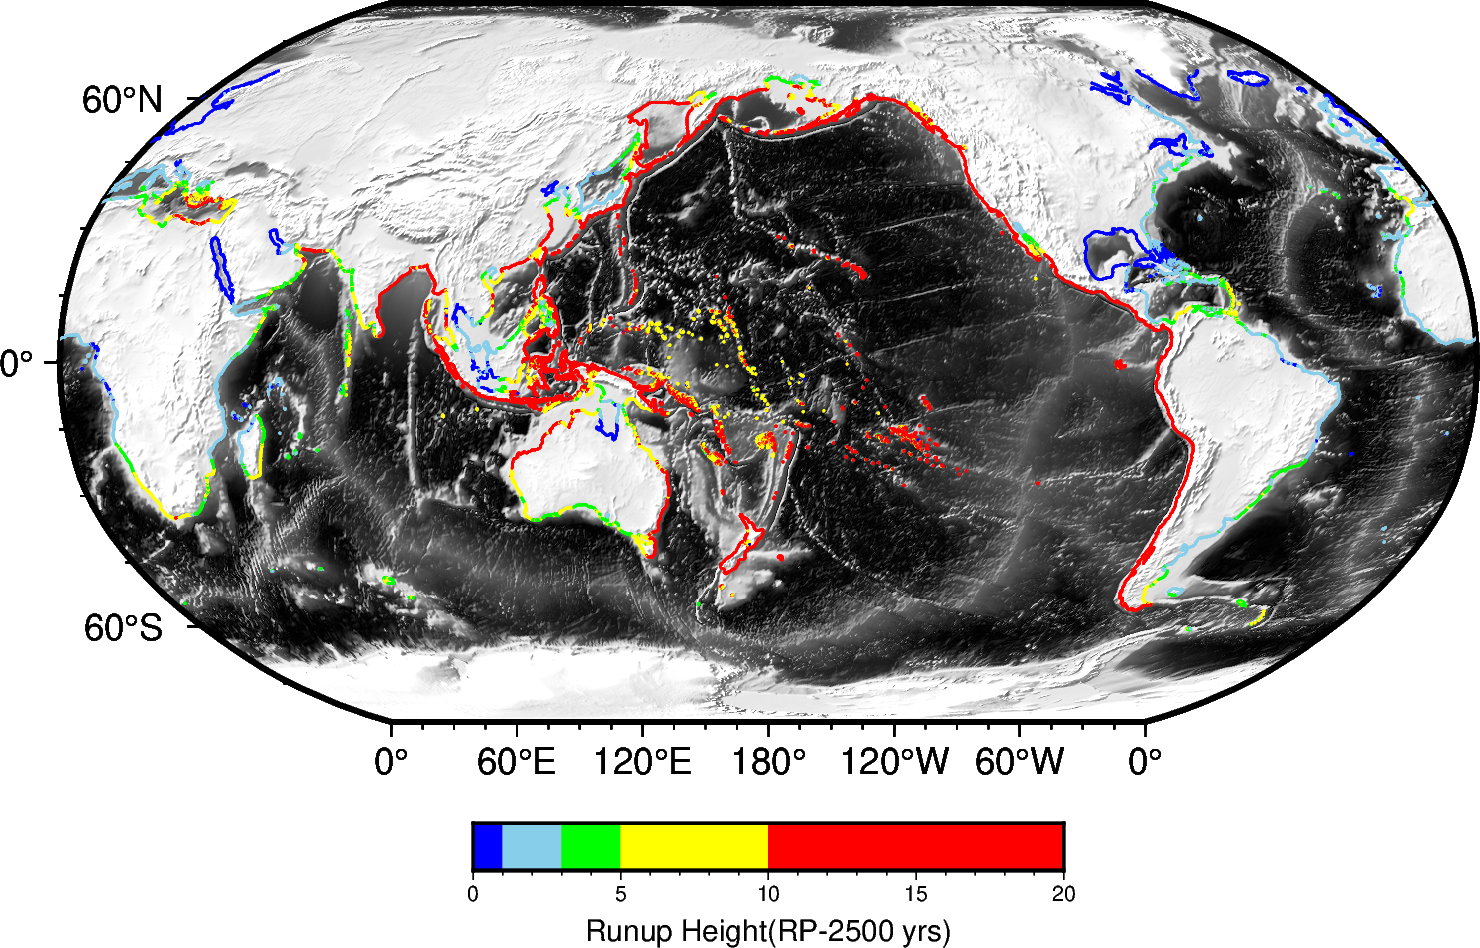

In [1]:
import pandas as pd
import pygmt

#csv files
ptha = pd.read_csv('./revised1_tsunami_runup_at_fixed_return_periods.csv')
pop = pd.read_csv('./GCC_socioeconomic.csv')

# Load the elevation grid globally for the whole Earth
grid = pygmt.datasets.load_earth_relief(resolution="15m")

#plot bathy and topography
fig = pygmt.Figure()
fig.basemap(region="g", projection="N12c", frame=True)
pygmt.makecpt(cmap="gray", series=[-5000, 500],transparency=80)
fig.grdimage(shading=True,frame=True, grid=grid,cmap=True,projection="N12c",)

#plot coast
# fig.coast(shorelines="0.1p,black,solid",region="g",projection="N12c")

#plots pop 
cmap = pygmt.makecpt(cmap='blue,skyblue,green,yellow,red',series = '0,1,3,5,10,20',continuous=False)
fig.plot(x=ptha.Lon, y=ptha.Lat,cmap=True,style='p0.02c',fill=ptha.ari2500,pen=None,projection="N12c")
fig.colorbar(frame=["x+lRunup Height(RP-2500 yrs)"], position="JBC+w5c/0.4c") #add colorbar legend for scatter
fig.savefig('ptha_map.png',dpi=300)
fig.show()


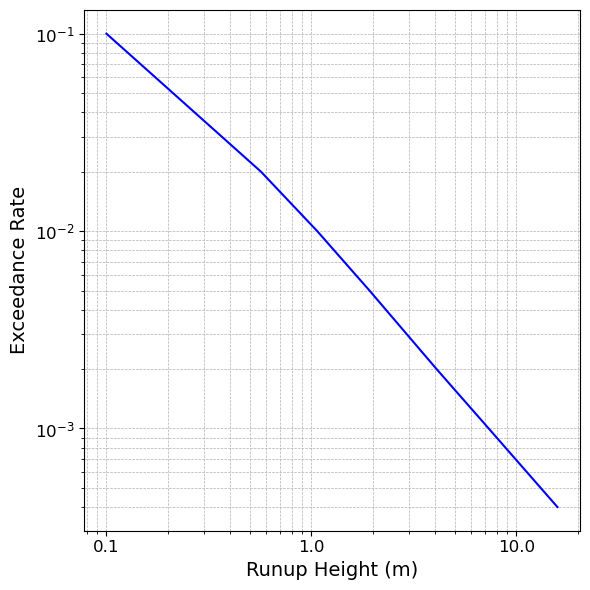

In [31]:
from matplotlib.ticker import ScalarFormatter

#plot hazard curve for a location with index 4742 ie Point (80.5303802490234375 13.21885013580322266)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))  # Increase figure size for better readability

RP = [10, 50, 100, 200, 500, 1000, 2500]
rate = [1/i for i in RP]
runup = [ptha.ari10[4742],ptha.ari50[4742],ptha.ari100[4742],ptha.ari200[4742],ptha.ari500[4742],ptha.ari1000[4742],ptha.ari2500[4742]]

ax.plot(runup, rate, linestyle='-', color='b', label='Hazard Curve')

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylabel('Exceedance Rate', fontsize=14)
ax.set_xlabel('Runup Height (m)', fontsize=14)

ax.grid(True, which="both", ls="--", linewidth=0.5)

# Set x-axis formatter to avoid scientific notation
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.get_major_formatter().set_scientific(False)
ax.xaxis.get_major_formatter().set_useOffset(False)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig('hazard_curve.png', dpi=100)
plt.show()
